In [80]:
import time
import numpy as np
import torch
from torchvision import datasets, transforms
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn as nn
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset, DataLoader
from fvcore.nn import FlopCountAnalysis
from networks import LeNet
from skimage import io

import pandas as pd
from PIL import Image
import os
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

In [81]:
# Hyperparameters
batch_size = 64
num_epochs = 20
learning_rate = 0.001

In [82]:
class MHISTDataset(Dataset):
    def __init__(self, csv_file, root_dir, partition='train',transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.annotations = self.annotations[self.annotations['Partition'] == partition]
        self.transform = transform

    def __len__(self):
        return len(self.annotations) #total images

    def __getitem__(self, index):
        img_path = os.path.join(self.root_dir, self.annotations.iloc[index, 0])
        image = io.imread(img_path)
        y_label = torch.tensor(int(self.annotations.iloc[index, 4]))
        
        
        if self.transform:
            image = self.transform(image)
        
        return (image,y_label)

In [83]:
transform = transforms.Compose([
    transforms.ToPILImage(),  # Convert the image to PIL format
    transforms.Resize((32, 32)),  # Resize the image to 32x32
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize image (for colored RGB images)
])

In [ ]:
dataset = MHISTDataset(csv_file = 'annotations.csv', root_dir = 'images', transform = transforms.ToTensor())

train_dataset = MHISTDataset(csv_file='annotations.csv', root_dir='images', partition='train', transform=transform)
test_dataset = MHISTDataset(csv_file='annotations.csv', root_dir='images', partition='test', transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch _size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [85]:
# Initialize the MLP model for MHIST
model = LeNet(channel=3, num_classes=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


# Define optimizer and cosine annealing scheduler
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

# Loss function
criterion = nn.CrossEntropyLoss()

Epoch [1/20], Training Loss: 0.7184, Validation Loss: 0.6938
Epoch [2/20], Training Loss: 0.6763, Validation Loss: 0.6791
Epoch [3/20], Training Loss: 0.6488, Validation Loss: 0.6732
Epoch [4/20], Training Loss: 0.6318, Validation Loss: 0.6722
Epoch [5/20], Training Loss: 0.6211, Validation Loss: 0.6735
Epoch [6/20], Training Loss: 0.6145, Validation Loss: 0.6760
Epoch [7/20], Training Loss: 0.6103, Validation Loss: 0.6788
Epoch [8/20], Training Loss: 0.6076, Validation Loss: 0.6813
Epoch [9/20], Training Loss: 0.6060, Validation Loss: 0.6834
Epoch [10/20], Training Loss: 0.6049, Validation Loss: 0.6854
Epoch [11/20], Training Loss: 0.6043, Validation Loss: 0.6871
Epoch [12/20], Training Loss: 0.6038, Validation Loss: 0.6880
Epoch [13/20], Training Loss: 0.6035, Validation Loss: 0.6888
Epoch [14/20], Training Loss: 0.6034, Validation Loss: 0.6895
Epoch [15/20], Training Loss: 0.6032, Validation Loss: 0.6900
Epoch [16/20], Training Loss: 0.6032, Validation Loss: 0.6903
Epoch [17/20], Tr

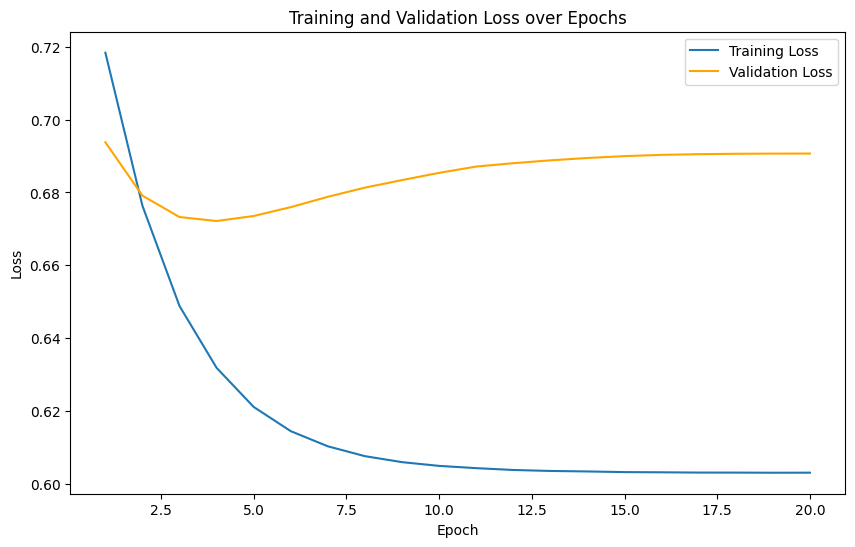

In [86]:
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score
import torch

# Train the model and record both training and validation loss
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)

    train_losses = []
    val_losses = []
    all_preds, all_labels = [], []

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0

        # Training loop
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        # Record average training loss
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation loop
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss = criterion(outputs, labels)
                total_val_loss += val_loss.item()

                # Record predictions and labels
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Record average validation loss
        avg_val_loss = total_val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        # Update learning rate
        scheduler.step()

        # Print epoch loss
        print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}')

    # Calculate accuracy for testing data based on `y_label`
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"Test Accuracy (y_label): {accuracy * 100:.2f}%")

    return train_losses, val_losses

# Plot training and validation losses
def plot_losses(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.legend()
    plt.show()

# Run training and plot
train_losses, val_losses = train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs)
plot_losses(train_losses, val_losses)
